<a href="https://colab.research.google.com/github/MaSBroEarl/Task.Text-generation/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_TextGeneration_%D0%91%D0%B5%D0%B7ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Импорты

In [ ]:
!pip install -q transformers datasets accelerate peft bitsandbytes trl
!pip install -q rouge-score nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.6 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize

In [ ]:
#настраиваем стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Загружаем данные

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df

,id,dialogue,summary,topic
0,train_0,"#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. ...","Mr. Smith's getting a check-up, and Doctor Haw...",get a check-up
1,train_1,"#Person1#: Hello Mrs. Parker, how have you bee...",Mrs Parker takes Ricky for his vaccines. Dr. P...,vaccines
2,train_2,"#Person1#: Excuse me, did you see a set of key...",#Person1#'s looking for a set of keys and asks...,find keys
3,train_3,#Person1#: Why didn't you tell me you had a gi...,#Person1#'s angry because #Person2# didn't tel...,have a girlfriend
4,train_4,"#Person1#: Watsup, ladies! Y'll looking'fine t...",Malik invites Nikki to dance. Nikki agrees if ...,dance
...,...,...,...,...
12455,train_12455,#Person1#: Excuse me. You are Mr. Green from M...,Tan Ling picks Mr. Green up who is easily reco...,pick up someone
12456,train_12456,#Person1#: Mister Ewing said we should show up...,#Person1# and #Person2# plan to take the under...,conference center
12457,train_12457,#Person1#: How can I help you today?\n#Person2...,#Person2# rents a small car for 5 days with th...,rent a car
12458,train_12458,#Person1#: You look a bit unhappy today. What'...,#Person2#'s mom lost her job. #Person2# hopes ...,job losing


# EDA
DialogSum Corpus — создан для исследований в области суммаризации диалогов и генерации тем.

Он содержит множество записей повседневных разговоров на разные темы: учёба, работа, покупки, путешествия, отдых, медицина и др.  Данные представлены в двух форматах: CSV и JSONL.

    Признаки:

    id: уникальный ID

    dialogue: текст разговора

    summary: краткое резюме от человека

    topic: тема диалога (одной строкой)


**Цель исследования:** повысить качество суммаризации

    => summary - целевая переменная

In [ ]:
# Подсчитаем статистики
def text_stats(text):
    """Подсчёт базовых метрик для текста"""
    if not isinstance(text, str):
        return {'words': 0, 'chars': 0, 'sentences': 0, 'avg_word_len': 0}
    words = text.split()
    chars = len(text)
    sentences = len(re.findall(r'[.!?]+', text))
    return {
        'words': len(words),
        'chars': chars,
        'sentences': sentences,
        'avg_word_len': chars / len(words) if len(words) > 0 else 0
    }

# Считаем статистику
df['dialog_stats'] = df['dialogue'].apply(text_stats)
df['summary_stats'] = df['summary'].apply(text_stats)

# Извлекаем метрики
for stat in ['words', 'sentences', 'avg_word_len']:
    df[f'dialog_{stat}'] = df['dialog_stats'].apply(lambda x: x[stat])
    df[f'summary_{stat}'] = df['summary_stats'].apply(lambda x: x[stat])

print("\n" + "="*50)
print("ОСНОВНАЯ СТАТИСТИКА")
print("="*50)
print(f"Всего диалогов: {len(df)}")
print(f"\nДиалог:")
print(f"  - слов: среднее {df['dialog_words'].mean():.1f}, медиана {df['dialog_words'].median():.0f}")
print(f"  - предложений: среднее {df['dialog_sentences'].mean():.1f}")
print(f"  - средняя длина слова: {df['dialog_avg_word_len'].mean():.2f}")
print(f"\nСуммаризация:")
print(f"  - слов: среднее {df['summary_words'].mean():.1f}, медиана {df['summary_words'].median():.0f}")
print(f"  - предложений: среднее {df['summary_sentences'].mean():.1f}")
print(f"  - средняя длина слова: {df['summary_avg_word_len'].mean():.2f}")


ОСНОВНАЯ СТАТИСТИКА
Всего диалогов: 12460

Диалог:
  - слов: среднее 131.0, медиана 116
  - предложений: среднее 17.2
  - средняя длина слова: 5.66

Суммаризация:
  - слов: среднее 22.9, медиана 21
  - предложений: среднее 1.9
  - средняя длина слова: 6.22



АНАЛИЗ ТЕМ
Всего уникальных тем: 7434

ТОП-10 тем:
  shopping: 174 (1.4%)
  job interview: 161 (1.3%)
  daily casual talk: 125 (1.0%)
  phone call: 89 (0.7%)
  order food: 79 (0.6%)
  interview: 77 (0.6%)
  social meeting: 56 (0.4%)
  business talk: 48 (0.4%)
  see a doctor: 46 (0.4%)
  weather: 42 (0.3%)

Средняя длина темы: 2.11 слов


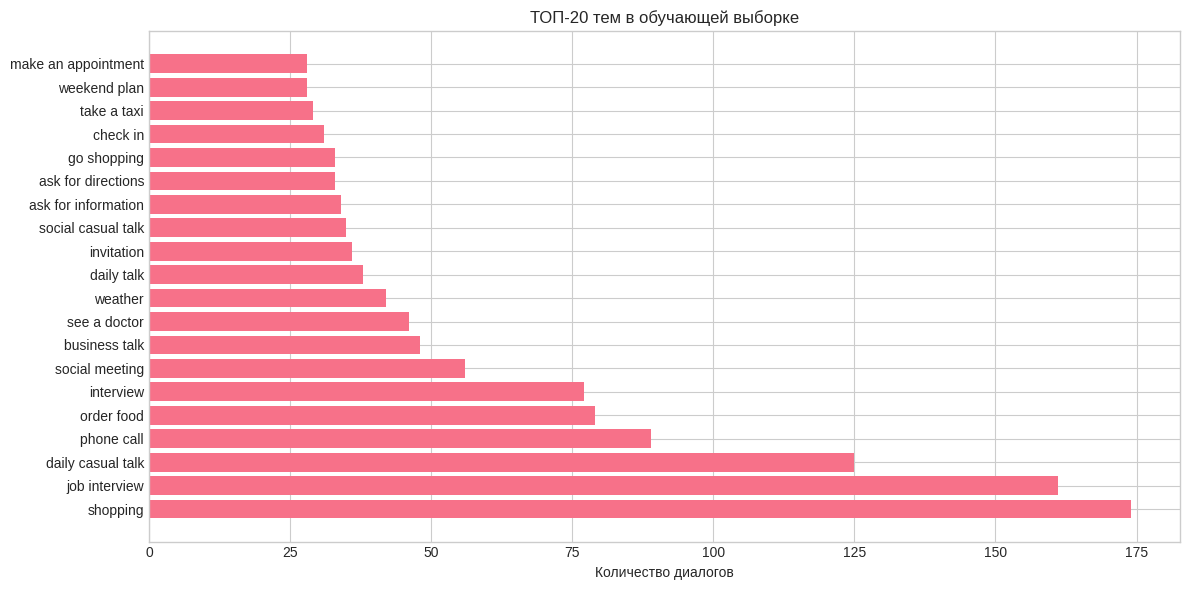

In [ ]:
# Темы

if 'topic' in df.columns:
    print("\n" + "="*50)
    print("АНАЛИЗ ТЕМ")
    print("="*50)

    topic_counts = df['topic'].value_counts()
    print(f"Всего уникальных тем: {len(topic_counts)}")
    print("\nТОП-10 тем:")
    for topic, count in topic_counts.head(10).items():
        print(f"  {topic}: {count} ({count/len(df)*100:.1f}%)")

    # Длина темы
    df['topic_len'] = df['topic'].apply(lambda x: len(str(x).split()))
    print(f"\nСредняя длина темы: {df['topic_len'].mean():.2f} слов")

    # Визуализация
    fig, ax = plt.subplots(figsize=(12, 6))
    top_topics = topic_counts.head(20)
    ax.barh(range(len(top_topics)), top_topics.values)
    ax.set_yticks(range(len(top_topics)))
    ax.set_yticklabels(top_topics.index)
    ax.set_xlabel('Количество диалогов')
    ax.set_title('ТОП-20 тем в обучающей выборке')
    plt.tight_layout()
    plt.savefig('eda_topics.png', dpi=150)
    plt.show()

# Бейзлайн без ML:

Складываем первое и последнее предложение

In [ ]:
# ФУНКЦИЯ ДЛЯ БЕЙЗЛАЙНА

def first_last_summary(dialogue):
    """
    Бейзлайн: берём первое и последнее предложение диалога
    """
    if not isinstance(dialogue, str):
        return ""

    # Убираем теги участников для чистоты
    clean_dialogue = re.sub(r'#Person\d+#', '', dialogue)

    # Разбиваем на предложения
    sentences = sent_tokenize(clean_dialogue)

    if len(sentences) == 0:
        return ""
    elif len(sentences) == 1:
        return sentences[0]
    else:
        # Берём первое и последнее предложение
        first = sentences[0].strip()
        last = sentences[-1].strip()

        # Если первое и последнее совпадают - возвращаем одно
        if first == last:
            return first
        else:
            return f"{first} {last}"

# Применяем бейзлайн
df['baseline_summary'] = df['dialogue'].apply(first_last_summary)

# Считаем длину
df['dialog_words'] = df['dialogue'].apply(lambda x: len(str(x).split()))
df['summary_words'] = df['summary'].apply(lambda x: len(str(x).split()))
df['baseline_words'] = df['baseline_summary'].apply(lambda x: len(str(x).split()))

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ БЕЙЗЛАЙНА")
print("="*50)
print(f"Средняя длина диалога: {df['dialog_words'].mean():.2f} слов")
print(f"Средняя длина референсной суммаризации: {df['summary_words'].mean():.2f} слов")
print(f"Средняя длина бейзлайн-суммаризации: {df['baseline_words'].mean():.2f} слов")



РЕЗУЛЬТАТЫ БЕЙЗЛАЙНА
Средняя длина диалога: 130.99 слов
Средняя длина референсной суммаризации: 22.87 слов
Средняя длина бейзлайн-суммаризации: 15.62 слов


Считаем метрики bleu/rouge

In [ ]:
# ОЦЕНКА КАЧЕСТВА (ROUGE, BLEU)

def evaluate_summaries(df, reference_col='summary', prediction_col='baseline_summary', sample_size=None):
    """
    Оценка суммаризаций с помощью ROUGE и BLEU
    """
    if sample_size:
        eval_df = df.head(sample_size).copy()
    else:
        eval_df = df.copy()

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothie = SmoothingFunction().method4

    rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    bleu_scores = []

    print(f"Оценка {len(eval_df)} примеров...")

    for idx, row in eval_df.iterrows():
        ref = str(row[reference_col])
        pred = str(row[prediction_col])

        if len(pred.strip()) == 0:
            pred = "empty"
            ref = "empty"

        try:
            # ROUGE
            scores = scorer.score(ref, pred)
            rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
            rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
            rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)

            # BLEU
            ref_tokens = ref.split()
            pred_tokens = pred.split()
            if len(pred_tokens) > 0:
                bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothie)
            else:
                bleu = 0
            bleu_scores.append(bleu)
        except Exception as e:
            # Пропускаем проблемные примеры
            continue

    return {
        'rouge1': np.mean(rouge_scores['rouge1']) if rouge_scores['rouge1'] else 0,
        'rouge2': np.mean(rouge_scores['rouge2']) if rouge_scores['rouge2'] else 0,
        'rougeL': np.mean(rouge_scores['rougeL']) if rouge_scores['rougeL'] else 0,
        'bleu': np.mean(bleu_scores) if bleu_scores else 0
    }

print("\n" + "="*50)
print("ОЦЕНКА КАЧЕСТВА БЕЙЗЛАЙНА")
print("="*50)

# Оцениваем на первых 500 для скорости
metrics = evaluate_summaries(df, sample_size=500)

print(f"ROUGE-1: {metrics['rouge1']:.4f}")
print(f"ROUGE-2: {metrics['rouge2']:.4f}")
print(f"ROUGE-L: {metrics['rougeL']:.4f}")
print(f"BLEU: {metrics['bleu']:.4f}")


ОЦЕНКА КАЧЕСТВА БЕЙЗЛАЙНА
Оценка 500 примеров...
ROUGE-1: 0.1778
ROUGE-2: 0.0617
ROUGE-L: 0.1548
BLEU: 0.0267
